In [ ]:
import nltk
from nltk.corpus import twitter_samples
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import random
import string

In [ ]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [ ]:
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
print('The number of positive tweets is: ', len(all_positive_tweets))
print('The number of negative tweets is: ', len(all_negative_tweets))

print('\n The type of all_positive_tweets is: ', type(all_positive_tweets))
print('The type of a tweet entry is: ', type(all_negative_tweets[0]))

The number of positive tweets is:  5000
The number of negative tweets is:  5000

 The type of all_positive_tweets is:  <class 'list'>
The type of a tweet entry is:  <class 'str'>


In [ ]:
import pandas as pd
positive_tweets=pd.DataFrame(all_positive_tweets, columns=["Tweets"])
negative_tweets=pd.DataFrame(all_negative_tweets, columns=["Tweets"])

In [ ]:
positive_tweets.head()

,Tweets
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...
1,@Lamb2ja Hey James! How odd :/ Please call our...
2,@DespiteOfficial we had a listen last night :)...
3,@97sides CONGRATS :)
4,yeaaaah yippppy!!! my accnt verified rqst has...


In [ ]:
positive_tweets['Sentiments'] = 'positive'

In [ ]:
negative_tweets['Sentiments'] = 'negative'

In [ ]:
positive_tweets.head()

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [ ]:
negative_tweets.head()

,Tweets,Sentiments
0,hopeless for tmr :(,negative
1,Everything in the kids section of IKEA is so c...,negative
2,@Hegelbon That heart sliding into the waste ba...,negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",negative
4,"Dang starting next week I have ""work"" :(",negative


In [ ]:
all_tweets=pd.concat([positive_tweets, negative_tweets], ignore_index=True)
all_tweets

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive
...,...,...
9995,I wanna change my avi but uSanele :(,negative
9996,MY PUPPY BROKE HER FOOT :(,negative
9997,where's all the jaebum baby pictures :((,negative
9998,But but Mr Ahmad Maslan cooks too :( https://t...,negative


In [ ]:
all_tweets = all_tweets.sample(frac=1, random_state=42).reset_index(drop=True)
all_tweets

,Tweets,Sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you...",negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,positive
2,"Your love, O Lord, is better than life. :) &lt...",positive
3,@yasminyasir96 yeah but it will be better if w...,positive
4,Ok good night I wish troye wasn't ugly and I m...,positive
...,...,...
9995,My nose and forehead are peeling :(,negative
9996,@LittleMix come to Belgium :(,negative
9997,WHY MUST THE VIDEO STOP THO :(,negative
9998,@jeremygutsche we like this amazing donut reci...,positive


In [ ]:
tweet1=all_tweets.iloc[555]
tweet1["Tweets"]

'i rly wanna spend christmas with my relatives this yr :('

In [ ]:
y_positive=(all_tweets["Sentiments"]=="positive").sum()
y_negative=(all_tweets["Sentiments"]=="negative").sum()
print("Number of positive tweets: ", y_positive)
print("Number of negative tweets: ", y_negative)

Number of positive tweets:  5000
Number of negative tweets:  5000


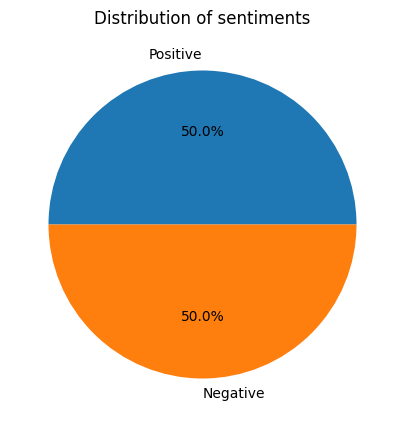

In [ ]:
fig=plt.figure(figsize=(5,5))
labels='Positive','Negative'
sizes=[y_positive, y_negative]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of sentiments')
plt.show()

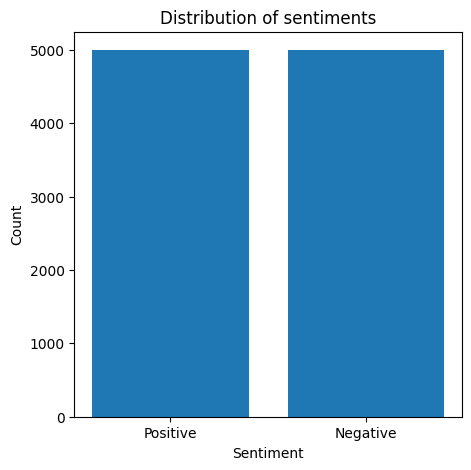

In [ ]:
fig=plt.figure(figsize=(5,5))
labels='Positive','Negative'
sizes=[y_positive, y_negative]
plt.bar(labels, sizes)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Distribution of sentiments')
plt.show()

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [ ]:
tweet2=re.sub(r'^RT[\s]+', '', tweet1["Tweets"])
tweet2 = re.sub(r'https?://\S+|www\.\S+', '', tweet2)

tweet2=re.sub(r'#','',tweet2)
tweet2=re.sub(r'~','',tweet2)
tweet2 = re.sub(r':\)|:\(', '', tweet2)
print(tweet1["Tweets"])
print("\ncleaned tweets: \n", tweet2)

i rly wanna spend christmas with my relatives this yr :(

cleaned tweets: 
 i rly wanna spend christmas with my relatives this yr 


In [ ]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
tweet_tokens = tokenizer.tokenize(tweet2)
print(tweet_tokens)

['i', 'rly', 'wanna', 'spend', 'christmas', 'with', 'my', 'relatives', 'this', 'yr']


In [ ]:
print()
print(tweet_tokens)
stopwords_english = stopwords.words('english')

tweets_clean=[]
for word in tweet_tokens:
    if(word not in stopwords_english and word not in string.punctuation):
        tweets_clean.append(word)
print('removed stopwords and punctuation: ')
print(tweets_clean)


['i', 'rly', 'wanna', 'spend', 'christmas', 'with', 'my', 'relatives', 'this', 'yr']
removed stopwords and punctuation: 
['rly', 'wanna', 'spend', 'christmas', 'relatives', 'yr']


In [ ]:
stemmer = PorterStemmer()
tweets_stem = []
for word in tweets_clean:
    stem_word = stemmer.stem(word)
    tweets_stem.append(stem_word)

print('stemmed words: ')
print(tweets_stem)

stemmed words: 
['rli', 'wanna', 'spend', 'christma', 'rel', 'yr']
